In [1]:
# PTB-XL xResnet1D Model
import os
import ast
import wfdb
import torch
import zipfile
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc

In [2]:
# Dataset and Preprocessing
from scipy import signal
dataset_path = Path("/users/PLS0150/shreeshtee/PTBXL-Dataset-Thesiswork/physionet.org/files/ptb-xl/1.0.3")
ptbxl_path = dataset_path / "ptbxl_database.csv"
waveform_path = dataset_path

df = pd.read_csv(ptbxl_path)
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)
df['scp_keys'] = df['scp_codes'].apply(lambda x: list(x.keys()))
target_labels = ['NORM', 'AFIB', 'PVC', 'LVH', 'IMI', 'ASMI', 'LAFB', 'IRBBB']
df['scp_filtered'] = df['scp_keys'].apply(lambda x: [k for k in x if k in target_labels])
df = df[df['scp_filtered'].map(len) > 0]
mlb = MultiLabelBinarizer(classes=target_labels)
y = mlb.fit_transform(df['scp_filtered'])
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2, random_state=42)

def load_ecg(record_path):
    record = wfdb.rdrecord(record_path)
    return record.p_signal

class PTBXL_Dataset(Dataset):
    def __init__(self, df, labels, base_dir):
        self.df = df
        self.labels = labels
        self.base_dir = base_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        full_path = os.path.join(self.base_dir, row['filename_lr'])
        signal = load_ecg(full_path).T
        return torch.tensor(signal, dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.float32)

train_dataset = PTBXL_Dataset(X_train, y_train, waveform_path)
test_dataset = PTBXL_Dataset(X_test, y_test, waveform_path)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=8, num_workers=2, pin_memory=True)
val_loader = DataLoader(test_dataset, batch_size=8, num_workers=2, pin_memory=True)

In [3]:
# XResNet1D Model Definition
class ConvLayer(nn.Sequential):
    """Conv1D + BatchNorm + optional activation."""
    def __init__(self, ni, nf, ks=3, stride=1, padding=None, bias=False, act_cls=nn.ReLU):
        if padding is None:
            padding = (ks - 1) // 2
        layers = [
            nn.Conv1d(ni, nf, kernel_size=ks, stride=stride, padding=padding, bias=bias),
            nn.BatchNorm1d(nf)
        ]
        if act_cls is not None:
            layers.append(act_cls())
        super().__init__(*layers)


class XResBlock(nn.Module):
    """
    xResNet residual block.
    Key difference from plain ResBlock:
      - Skip uses AvgPool1d + 1x1 conv when downsampling (not strided 1x1 conv alone).
      - Main path uses stride=1 conv + separate AvgPool1d for downsampling.
    """
    def __init__(self, ni, nf, stride=1):
        super().__init__()
        # Main path: two Conv k=3 layers; downsampling handled by AvgPool after
        self.convs = nn.Sequential(
            ConvLayer(ni, nf, ks=3, stride=1),   # stride=1 always here
            ConvLayer(nf, nf, ks=3, stride=1, act_cls=None)
        )
        # FIX 3: Skip connection uses AvgPool + 1x1 conv when striding
        if ni == nf and stride == 1:
            self.skip = nn.Identity()
        else:
            self.skip = nn.Sequential(
                nn.AvgPool1d(kernel_size=stride, stride=stride, ceil_mode=True),  # anti-aliased downsample
                ConvLayer(ni, nf, ks=1, stride=1, act_cls=None)                  # 1x1 projection
            )
        # FIX 2: AvgPool on main path for downsampling (not strided conv)
        self.pool = nn.AvgPool1d(kernel_size=stride, stride=stride, ceil_mode=True) if stride > 1 else nn.Identity()
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.pool(self.convs(x)) + self.skip(x))


class XResNet1d(nn.Module):
    """
    True xResNet1D for ECG classification.
    Input:  (batch, 12, 1000)  -- 12 leads x 1000 time points
    Output: (batch, 8)         -- 8 diagnostic classes, sigmoid activated

    Architecture:
      Stem        : Conv k=3 (12->32) -> Conv k=3 (32->32) -> Conv k=3 (32->64) -> AvgPool
      Res Block 1 : XResBlock x2  64 -> 128,  stride=2, output ~250t
      Res Block 2 : XResBlock x2  128 -> 256, stride=2, output ~125t
      Res Block 3 : XResBlock x2  256 -> 512, stride=2, output ~62t
      Global Pool : AdaptiveAvgPool1d(1) -> 512
      Head        : Linear 512->256, ReLU, Dropout(0.2), Linear 256->8, Sigmoid
    """
    def __init__(self, input_channels=12, num_classes=8, n_blocks=(2, 2, 2)):
        super().__init__()

        # FIX 1: 3-conv stem with k=3 (xResNet hallmark)
        self.stem = nn.Sequential(
            ConvLayer(input_channels, 32, ks=3, stride=1),   # 12 -> 32
            ConvLayer(32,             32, ks=3, stride=1),   # 32 -> 32
            ConvLayer(32,             64, ks=3, stride=2),   # 32 -> 64, halve length: 1000 -> 500
            nn.AvgPool1d(kernel_size=3, stride=2, padding=1) # FIX 2: AvgPool (500 -> 250... ~250t after stem)
        )

        # Residual block groups: 64->128, 128->256, 256->512
        block_sizes = [64, 128, 256, 512]
        self.layer1 = self._make_layer(block_sizes[0], block_sizes[1], n_blocks[0], stride=2)  # ~250t -> ~125t
        self.layer2 = self._make_layer(block_sizes[1], block_sizes[2], n_blocks[1], stride=2)  # ~125t -> ~62t
        self.layer3 = self._make_layer(block_sizes[2], block_sizes[3], n_blocks[2], stride=2)  # ~62t  -> ~31t

        # Global average pool collapses time dimension
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        # FIX 4: Full classifier head matching diagram
        self.head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, num_classes),
            nn.Sigmoid()
        )

    def _make_layer(self, ni, nf, n_blocks, stride):
        layers = [XResBlock(ni, nf, stride=stride)]  # first block downsamples
        for _ in range(1, n_blocks):
            layers.append(XResBlock(nf, nf, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.global_pool(x).squeeze(-1)  # (batch, 512)
        x = self.head(x)                      # (batch, 8)
        return x

In [4]:
# Training loop with Weights & Biases logging
import wandb

wandb.init(
    project="Hybrid-CNN-Transformer-ECG-notebooks_individual_notebooks",
    name="xResNet"
)

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: sdhakal13 (sdhakal13-youngstown-state-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [5]:
import numpy as np
from sklearn.metrics import roc_auc_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# FIX 5: Use true XResNet1d (3 block groups, 8 classes)
model = XResNet1d(
    input_channels=12,
    num_classes=len(target_labels),  # 8
    n_blocks=(2, 2, 2)               # 3 residual block groups
).to(device)

# NOTE: Model now outputs Sigmoid, so use BCELoss (not BCEWithLogitsLoss)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 100

for epoch in range(epochs):

    # ================= TRAIN =================
    model.train()
    total_loss, correct, total = 0, 0, 0

    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")

    for signals, labels in train_loader_tqdm:
        signals, labels = signals.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(signals)  # already sigmoid activated
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * signals.size(0)

        preds = (outputs > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.numel()

        train_loader_tqdm.set_postfix(loss=loss.item())

    train_loss = total_loss / len(train_loader.dataset)
    train_acc = correct / total

    # ================= VALIDATION =================
    model.eval()
    val_preds, val_labels_list = [], []
    val_loss = 0.0

    with torch.no_grad():
        for signals, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
            signals, labels = signals.to(device), labels.to(device)

            outputs = model(signals)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * signals.size(0)

            val_preds.append(outputs.cpu().numpy())
            val_labels_list.append(labels.cpu().numpy())

    val_loss /= len(val_loader.dataset)

    val_preds = np.vstack(val_preds)
    val_labels = np.vstack(val_labels_list)

    try:
        val_auc = roc_auc_score(val_labels, val_preds, average='macro')
    except Exception as e:
        val_auc = 0.0
        print("AUC error:", e)

    # ================= LOG =================
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_loss,
        "val_auc": val_auc
    })

    # ================= PRINT =================
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}")

Epoch 1/100 [Val]: 100%|██████████| 447/447 [01:11<00:00,  6.27it/s]


Epoch 1 | Train Loss: 0.2891 | Train Acc: 0.8902 | Val Loss: 0.2827 | Val AUC: 0.8369


Epoch 2/100 [Val]: 100%|██████████| 447/447 [00:05<00:00, 77.19it/s]


Epoch 2 | Train Loss: 0.2442 | Train Acc: 0.9045 | Val Loss: 0.2361 | Val AUC: 0.8990


Epoch 3/100 [Val]: 100%|██████████| 447/447 [00:05<00:00, 80.46it/s]


...

Epoch 98 | Train Loss: 0.0088 | Train Acc: 0.9969 | Val Loss: 0.4614 | Val AUC: 0.9505


Epoch 99/100 [Val]: 100%|██████████| 447/447 [00:05<00:00, 78.97it/s]


Epoch 99 | Train Loss: 0.0082 | Train Acc: 0.9974 | Val Loss: 0.4894 | Val AUC: 0.9545


Epoch 100/100 [Val]: 100%|██████████| 447/447 [00:05<00:00, 78.95it/s]

Epoch 100 | Train Loss: 0.0082 | Train Acc: 0.9973 | Val Loss: 0.4964 | Val AUC: 0.9533


In [6]:
# Evaluation
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for signals, labels in test_loader:
        signals, labels = signals.to(device), labels.to(device)
        outputs = model(signals)
        y_true.append(labels.cpu().numpy())
        y_pred.append(torch.sigmoid(outputs).cpu().numpy())

y_true = np.vstack(y_true)
y_pred = np.vstack(y_pred)

print("Classification Report:")
print(classification_report(y_true > 0.5, y_pred > 0.5, target_names=mlb.classes_))
print("Macro ROC-AUC:", roc_auc_score(y_true, y_pred, average='macro'))

Classification Report:
              precision    recall  f1-score   support

        NORM       0.66      0.99      0.80      1878
        AFIB       0.53      0.96      0.68       298
         PVC       0.35      0.96      0.51       257
         LVH       0.25      0.92      0.39       409
         IMI       0.30      0.95      0.46       558
        ASMI       0.38      0.96      0.55       458
        LAFB       0.43      0.96      0.59       345
       IRBBB       0.24      0.94      0.38       233

   micro avg       0.42      0.97      0.59      4436
   macro avg       0.39      0.95      0.55      4436
weighted avg       0.48      0.97      0.63      4436
 samples avg       0.57      0.97      0.67      4436

Macro ROC-AUC: 0.945976860335694


In [8]:
# COLLECT XRESNET PREDICTIONS
model.eval()
y_true_xresnet = []
y_pred_xresnet = []

with torch.no_grad():
    for signals, labels in tqdm(test_loader, desc='Evaluating XResNet1D'):
        signals = signals.to(device)
        outputs = model(signals)
        y_pred_xresnet.append(torch.sigmoid(outputs).cpu().numpy())
        y_true_xresnet.append(labels.numpy())

y_true_xresnet = np.vstack(y_true_xresnet)
y_pred_xresnet = np.vstack(y_pred_xresnet)

print(f"Collected {len(y_true_xresnet)} test samples")

Evaluating XResNet1D: 100%|██████████| 447/447 [00:05<00:00, 78.49it/s]

Collected 3576 test samples


In [9]:
# Helper function to compute macro-average ROC
def compute_macro_roc(y_true, y_pred):
    from sklearn.metrics import roc_curve, auc
    import numpy as np

    n_classes = y_true.shape[1]
    fpr_dict, tpr_dict, roc_auc_dict = {}, {}, {}

    for i in range(n_classes):
        fpr_dict[i], tpr_dict[i], _ = roc_curve(y_true[:, i], y_pred[:, i])
        roc_auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])

    all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)

    return all_fpr, mean_tpr, macro_auc

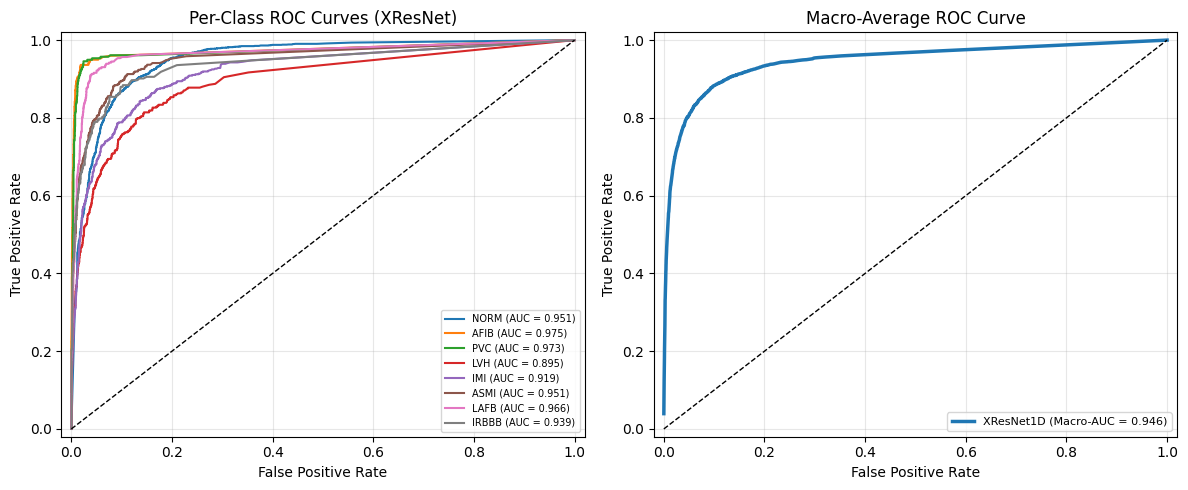

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Use XResNet predictions
y_true = np.array(y_true_xresnet)
y_pred = np.array(y_pred_xresnet)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# LEFT: Per-class ROC

fpr_dict = {}
tpr_dict = {}

for i, label in enumerate(target_labels):
    if len(np.unique(y_true[:, i])) < 2:
        continue

    fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)

    fpr_dict[i] = fpr
    tpr_dict[i] = tpr

    axes[0].plot(fpr, tpr, lw=1.5, label=f'{label} (AUC = {roc_auc:.3f})')

# Diagonal
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)

axes[0].set_xlim([-0.02, 1.02])
axes[0].set_ylim([-0.02, 1.02])
axes[0].set_title('Per-Class ROC Curves (XResNet)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.3)

# RIGHT: Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in fpr_dict]))

mean_tpr = np.zeros_like(all_fpr)

for i in fpr_dict:
    mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])

mean_tpr /= len(fpr_dict)

macro_auc = auc(all_fpr, mean_tpr)

axes[1].plot(all_fpr, mean_tpr,
             lw=2.5,
             label=f'XResNet1D (Macro-AUC = {macro_auc:.3f})')

# Diagonal
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlim([-0.02, 1.02])
axes[1].set_ylim([-0.02, 1.02])
axes[1].set_title('Macro-Average ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# Layout + Save
plt.tight_layout()
plt.savefig('xresnet_roc_model.png', dpi=300, bbox_inches='tight')
plt.show()